In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import MarkerCluster

In [37]:
df = pd.read_csv('C5-FestDataset - fest_dataset.csv')
print("Data loaded successfully. Shape:", df.shape)
print(df.head())

Data loaded successfully. Shape: (250, 10)
  Student Name            College  Phone Number    Place          State  \
0     Student1    Anna University    9100000001    Kochi         Kerala   
1     Student2  Amrita University    9100000002  Chennai     Tamil Nadu   
2     Student3         RV College    9100000003    Noida  Uttar Pradesh   
3     Student4    Anna University    9100000004    Kochi         Kerala   
4     Student5  Christ University    9100000005  Vellore     Tamil Nadu   

           Event Name  Event Type  Amount Paid  \
0    Coding Challenge  Individual          200   
1    Coding Challenge  Individual          200   
2           Hackathon       Group          500   
3        Project Expo       Group          400   
4  Paper Presentation  Individual          250   

                   Feedback on Fest  Rating  
0              Excellent experience       3  
1              Excellent experience       3  
2               Fun and informative       5  
3            Challeng

Event-wise participation:
Event Name
Paper Presentation    42
UI Design             41
Debugging Contest     40
Coding Challenge      36
Project Expo          34
Hackathon             31
Quiz Competition      26
Name: count, dtype: int64


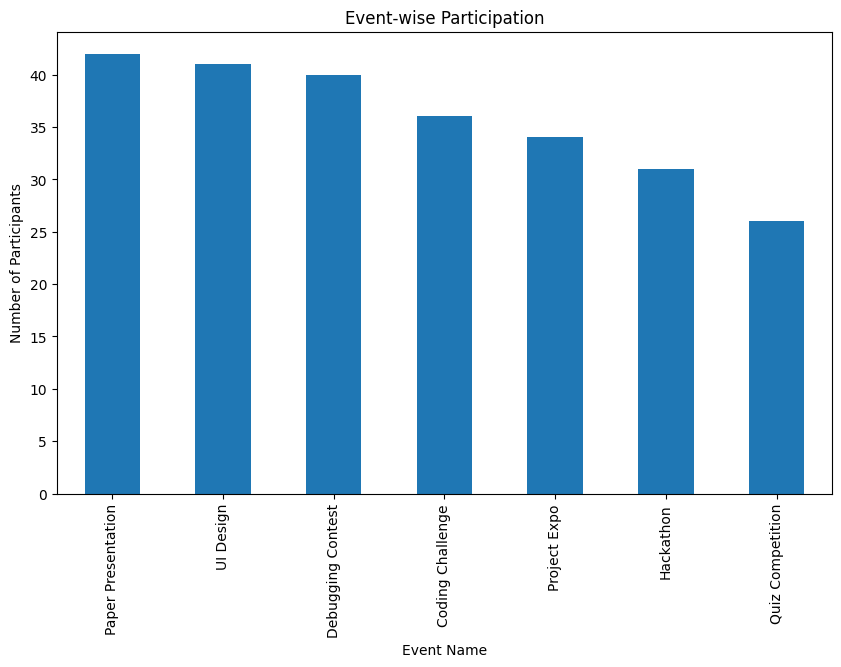

In [38]:
# Event-wise participation
event_counts = df['Event Name'].value_counts()
print("Event-wise participation:")
print(event_counts)

plt.figure(figsize=(10,6))
event_counts.plot(kind='bar')
plt.title('Event-wise Participation')
plt.xlabel('Event Name')
plt.ylabel('Number of Participants')
plt.show()


College-wise participation:
College
IIT Madras           25
PES University       23
Christ University    21
MIT Pune             21
Amrita University    21
Anna University      18
Delhi University     18
BITS Pilani          16
SRM Institute        15
RV College           14
Name: count, dtype: int64


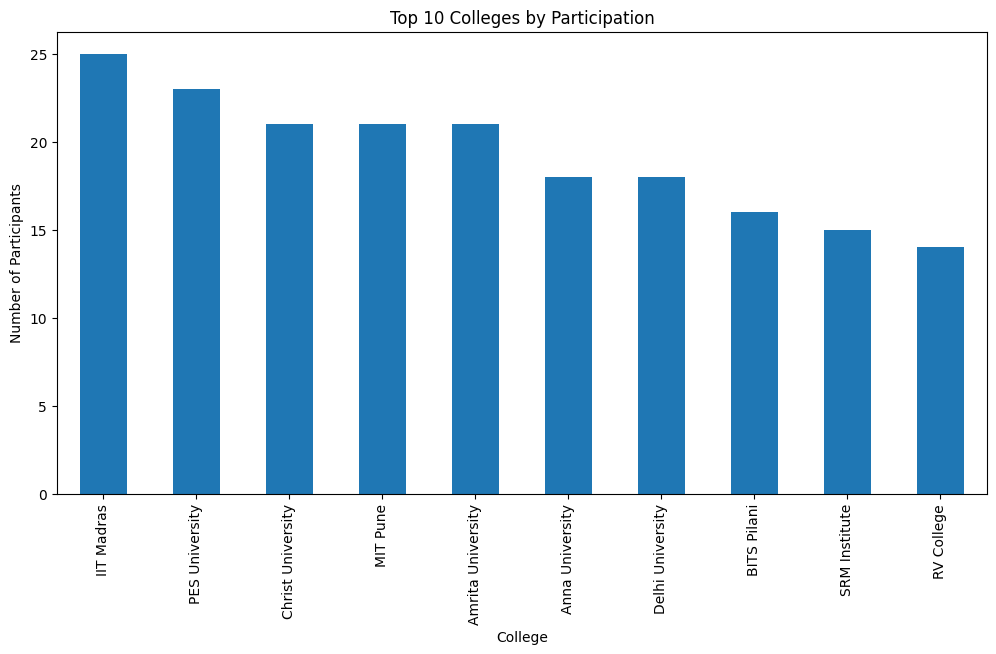

In [39]:
# College-wise participation
college_counts = df['College'].value_counts()
print("\nCollege-wise participation:")
print(college_counts.head(10))  # Top 10

plt.figure(figsize=(12,6))
college_counts.head(10).plot(kind='bar')
plt.title('Top 10 Colleges by Participation')
plt.xlabel('College')
plt.ylabel('Number of Participants')
plt.show()


State-wise participation:
State
Karnataka        50
Tamil Nadu       42
Rajasthan        29
Gujarat          29
Kerala           23
Delhi            22
Maharashtra      22
Uttar Pradesh    20
Telangana        13
Name: count, dtype: int64


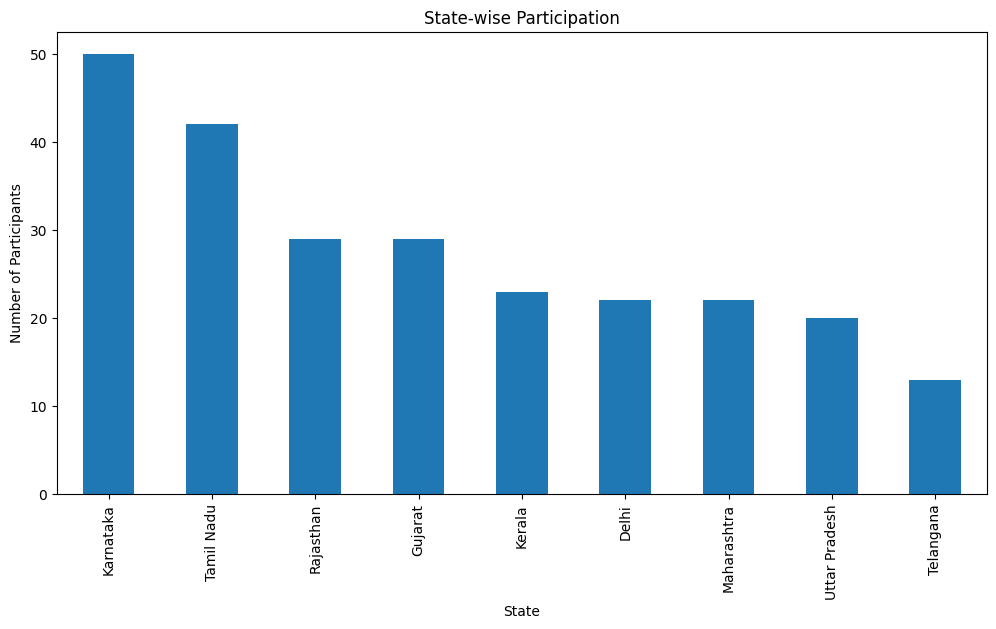

In [40]:
# State-wise participation
state_counts = df['State'].value_counts()
print("\nState-wise participation:")
print(state_counts)

plt.figure(figsize=(12,6))
state_counts.plot(kind='bar')
plt.title('State-wise Participation')
plt.xlabel('State')
plt.ylabel('Number of Participants')
plt.show()

In [41]:

state_coords = {
    'Maharashtra': [19.0760, 72.8777],
    'Karnataka': [12.9716, 77.5946],
    'Tamil Nadu': [13.0827, 80.2707],
    'Uttar Pradesh': [26.8467, 80.9462],
    'Gujarat': [23.0225, 72.5714],
    'Rajasthan': [26.9124, 75.7873],
    'Kerala': [8.5241, 76.9366],
    'Delhi': [28.7041, 77.1025],
    'Telangana': [17.3850, 78.4867],
    'West Bengal': [22.5726, 88.3639],
    'Punjab': [30.7333, 76.7794],
    'Haryana': [29.0588, 76.0856],
    'Madhya Pradesh': [22.9734, 78.6569],
    'Bihar': [25.0961, 85.3131],
    'Andhra Pradesh': [17.6868, 83.2185],
    'Odisha': [20.9517, 85.0985],
    'Chhattisgarh': [21.2787, 81.8661],
    'Jharkhand': [23.6102, 85.2799],
    'Uttarakhand': [30.0668, 79.0193],
    'Himachal Pradesh': [31.1048, 77.1734],
    'Jammu and Kashmir': [34.0837, 74.7973],
    'Goa': [15.2993, 74.1240],
    'Puducherry': [11.9416, 79.8083],
    'Chandigarh': [30.7333, 76.7794],
    'Sikkim': [27.5330, 88.5122],
    'Arunachal Pradesh': [27.1020, 93.6166],
    'Nagaland': [25.6586, 94.1053],
    'Manipur': [24.8170, 93.9368],
    'Mizoram': [23.1645, 92.9376],
    'Tripura': [23.9408, 91.9882],
    'Meghalaya': [25.4670, 91.3662],
    'Assam': [26.2006, 92.9376],
    'Ladakh': [34.1526, 77.5771]
}

# Create map centered on India
india_map = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# Add markers for each state with participant count
for state, count in state_counts.items():
    if state in state_coords:
        lat, lon = state_coords[state]
        folium.Marker(
            location=[lat, lon],
            popup=f"{state}: {count} participants",
            tooltip=f"{state}: {count}",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(india_map)

india_map


Event Type wise participation:
Event Type
Individual    159
Group          91
Name: count, dtype: int64


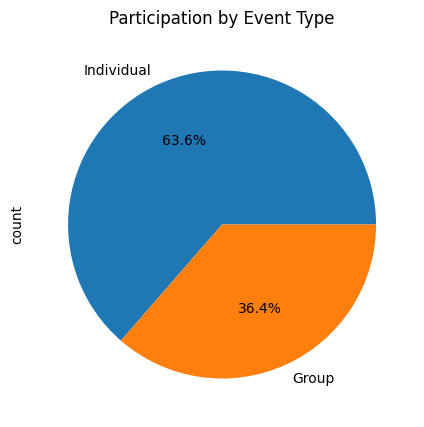


Total Revenue: ₹68800

Revenue per State:
State
Karnataka        13350
Tamil Nadu       11350
Rajasthan         8250
Kerala            7600
Gujarat           7600
Uttar Pradesh     5950
Maharashtra       5950
Delhi             5300
Telangana         3450
Name: Amount Paid, dtype: int64


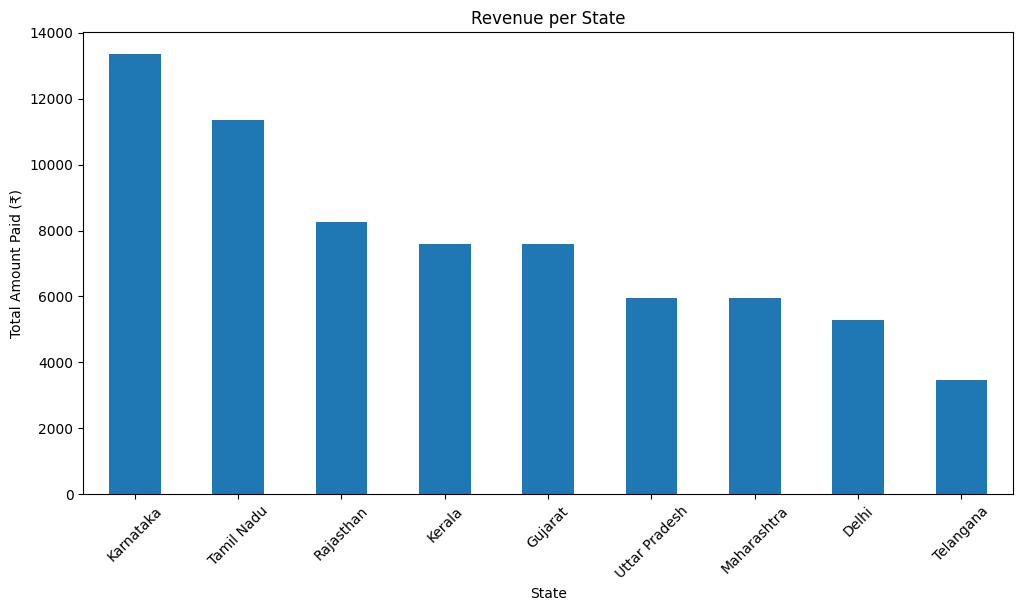

In [42]:
# Additional trends: Event Type wise
event_type_counts = df['Event Type'].value_counts()
print("\nEvent Type wise participation:")
print(event_type_counts)

plt.figure(figsize=(8,5))
event_type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Participation by Event Type')
plt.show()

# Total revenue (Amount Paid)
total_revenue = df['Amount Paid'].sum()
print(f"\nTotal Revenue: ₹{total_revenue}")

# Revenue per state
revenue_state = df.groupby('State')['Amount Paid'].sum().sort_values(ascending=False)
print("\nRevenue per State:")
print(revenue_state)

plt.figure(figsize=(12,6))
revenue_state.plot(kind='bar')
plt.title('Revenue per State')
plt.xlabel('State')
plt.ylabel('Total Amount Paid (₹)')
plt.xticks(rotation=45)
plt.show()